# Hoja de Trabajo 2 — DCGAN para sprites de Pokémon
Juan Diego Solís Martínez - 23720

Victor Manuel Pérez Chávez - 23714

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR = '/content/drive/MyDrive/dl_ht2'
SPRITE_DIR = os.path.join(BASE_DIR, 'pokemon_sprites')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## - Dependencias e imports

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

Dispositivo: cpu


## - Parámetros

In [4]:
# Parámetros fijos (mismos que Task 1)
Z_DIM = 100
IMG_SIZE = 64
IMG_CHANNELS = 3
FEATURES_G = 64
FEATURES_D = 64

# Entrenamiento Task 2.1
BATCH_SIZE = 32
NUM_EPOCHS = 20
LR  = 2e-4
BETAS = (0.5, 0.999)
D_STEPS = 5

print(f'Pasos D por paso G: {D_STEPS}  ->  balance deliberadamente asimétrico')

Pasos D por paso G: 5  ->  balance deliberadamente asimétrico


## - Dataset (mismos sprites de Task 1)

In [5]:
class PokemonDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir  = image_dir
        self.transform  = transform
        self.image_files = [
            f for f in os.listdir(image_dir)
            if f.endswith('.png') or f.endswith('.jpg')
        ]
        print(f'Dataset: {len(self.image_files)} imágenes')

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img = Image.open(
            os.path.join(self.image_dir, self.image_files[idx])
        ).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

BASE_DIR = '/content/drive/MyDrive/dl_ht2'
SPRITE_DIR = os.path.join(BASE_DIR, 'pokemon_sprites')
dataset    = PokemonDataset(SPRITE_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)

print(f'Batches por época: {len(dataloader)}')

Dataset: 898 imágenes
Batches por época: 28


## - Arquitecturas (idénticas a Task 1.1)

In [6]:
# Inicialización Radford
# Conv ~ N(0,0.02), BN gamma~N(1,0.02), beta=0
def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)

        elif isinstance(m, nn.BatchNorm2d):
            nn.init.normal_(m.weight.data, 1.0, 0.02)
            nn.init.constant_(m.bias.data, 0)

# z (B,100,1,1) -> imagen (B,3,64,64)
# 5x ConvTranspose2d | BN+ReLU en capas 1-4 | Tanh en capa 5
class Generator(nn.Module):
    def __init__(self, z_dim, img_channels, features_g):
        super().__init__()
        self.net = nn.Sequential(
            self._block(z_dim,        features_g*8, 4, 1, 0),  # →4x4
            self._block(features_g*8, features_g*4, 4, 2, 1),  # →8x8
            self._block(features_g*4, features_g*2, 4, 2, 1),  # →16x16
            self._block(features_g*2, features_g,   4, 2, 1),  # →32x32
            nn.ConvTranspose2d(features_g, img_channels, 4, 2, 1),  # →64x64
            nn.Tanh()
        )

    def _block(self, in_c, out_c, k, s, p):
        return nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, k, s, p, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, z):
        return self.net(z)

# imagen (B,3,64,64) → escalar (B,)
class Discriminator(nn.Module):
    def __init__(self, img_channels, features_d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(img_channels, features_d, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            self._block(features_d,   features_d*2, 4, 2, 1),
            self._block(features_d*2, features_d*4, 4, 2, 1),
            self._block(features_d*4, features_d*8, 4, 2, 1),
            nn.Conv2d(features_d*8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def _block(self, in_c, out_c, k, s, p):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, k, s, p, bias=False),
            nn.BatchNorm2d(out_c),
            nn.LeakyReLU(0.2, inplace=True)
        )

    def forward(self, x):
        return self.net(x).view(-1)


G = Generator(Z_DIM, IMG_CHANNELS, FEATURES_G).to(device)
D = Discriminator(IMG_CHANNELS, FEATURES_D).to(device)
initialize_weights(G)
initialize_weights(D)

# Verificación
z_t = torch.randn(4, Z_DIM, 1, 1).to(device)
assert G(z_t).shape == (4, 3, 64, 64)
assert D(torch.randn(4, 3, 64, 64).to(device)).shape == (4,)
print('Arquitecturas OK')

Arquitecturas OK


## Task 2.1 | Loop de entrenamiento con modo colapso deliberado

**Modificación clave:** por cada batch se ejecutan **5 pasos completos de D** antes del único paso de G.
Con esto D converje rápido a clasificar todas las imágenes falsas como 0,
vaciando el gradiente que recibe G.

In [7]:
criterion = nn.BCELoss()
opt_D = optim.Adam(D.parameters(), lr=LR, betas=BETAS)
opt_G = optim.Adam(G.parameters(), lr=LR, betas=BETAS)

fixed_noise = torch.randn(16, Z_DIM, 1, 1).to(device)

history_loss_G = []
history_loss_D = []
os.makedirs('collapse_grids', exist_ok=True)

G.train()
D.train()

for epoch in range(1, NUM_EPOCHS + 1):
    ep_loss_G, ep_loss_D, n_batches = 0.0, 0.0, 0

    for real_imgs in dataloader:
        real_imgs = real_imgs.to(device)
        bsz = real_imgs.size(0)

        # -- D_STEPS pasos del discriminador --
        # Con D_STEPS=5 el discriminador aprende a asignar D(G(z))≈0 para cualquier salida del generador.
        total_loss_D = 0.0
        for _ in range(D_STEPS):
            D.zero_grad()

            # Reales -> etiqueta 1
            pred_real   = D(real_imgs)
            loss_D_real = criterion(pred_real, torch.ones(bsz).to(device))

            # Falsos -> etiqueta 0
            noise      = torch.randn(bsz, Z_DIM, 1, 1).to(device)
            fake_imgs  = G(noise)
            pred_fake  = D(fake_imgs.detach())
            loss_D_fake = criterion(pred_fake, torch.zeros(bsz).to(device))

            loss_D = loss_D_real + loss_D_fake
            loss_D.backward()
            opt_D.step()
            total_loss_D += loss_D.item()

        avg_loss_D_batch = total_loss_D / D_STEPS

        # -- 1 paso del generador --
        # En este punto D(G(z))≈0 para casi toda z, por lo que el
        # gradiente ∇_θG L_G ≈ 0 -> G no se actualiza efectivamente.
        G.zero_grad()
        noise_G    = torch.randn(bsz, Z_DIM, 1, 1).to(device)
        fake_imgs_G = G(noise_G)
        pred_G     = D(fake_imgs_G)
        loss_G     = criterion(pred_G, torch.ones(bsz).to(device))
        loss_G.backward()
        opt_G.step()

        ep_loss_D += avg_loss_D_batch
        ep_loss_G += loss_G.item()
        n_batches += 1

    avg_D = ep_loss_D / n_batches
    avg_G = ep_loss_G / n_batches
    history_loss_D.append(avg_D)
    history_loss_G.append(avg_G)

    # Guardar grilla con ruido fijo
    G.eval()
    with torch.no_grad():
        fake_fixed = G(fixed_noise).cpu()
    G.train()
    grid = vutils.make_grid(fake_fixed, nrow=4, normalize=True)
    plt.imsave(f'collapse_grids/epoch_{epoch:02d}.png',
               grid.permute(1,2,0).numpy())

    print(f'Época [{epoch:2d}/{NUM_EPOCHS}]  '
          f'loss_D: {avg_D:.4f}  loss_G: {avg_G:.4f}')

print('\nEntrenamiento completado.')

Época [ 1/20]  loss_D: 0.1185  loss_G: 19.3117
Época [ 2/20]  loss_D: 0.0002  loss_G: 34.5784
Época [ 3/20]  loss_D: 0.1070  loss_G: 34.7856
Época [ 4/20]  loss_D: 0.0000  loss_G: 35.8314
Época [ 5/20]  loss_D: 0.0000  loss_G: 35.2623
Época [ 6/20]  loss_D: 1.1103  loss_G: 21.3688
Época [ 7/20]  loss_D: 0.4089  loss_G: 7.6404
Época [ 8/20]  loss_D: 0.2388  loss_G: 6.6173
Época [ 9/20]  loss_D: 0.1641  loss_G: 6.7913
Época [10/20]  loss_D: 0.0806  loss_G: 7.0761
Época [11/20]  loss_D: 0.1744  loss_G: 6.5122
Época [12/20]  loss_D: 0.2769  loss_G: 5.7277
Época [13/20]  loss_D: 0.0944  loss_G: 6.8163
Época [14/20]  loss_D: 0.0572  loss_G: 6.5263
Época [15/20]  loss_D: 0.2076  loss_G: 7.5944
Época [16/20]  loss_D: 0.3444  loss_G: 6.6035
Época [17/20]  loss_D: 0.1892  loss_G: 7.1129
Época [18/20]  loss_D: 0.1449  loss_G: 7.8886
Época [19/20]  loss_D: 0.1982  loss_G: 5.8766
Época [20/20]  loss_D: 0.2470  loss_G: 5.8301

Entrenamiento completado.


## Visualización del modo colapso

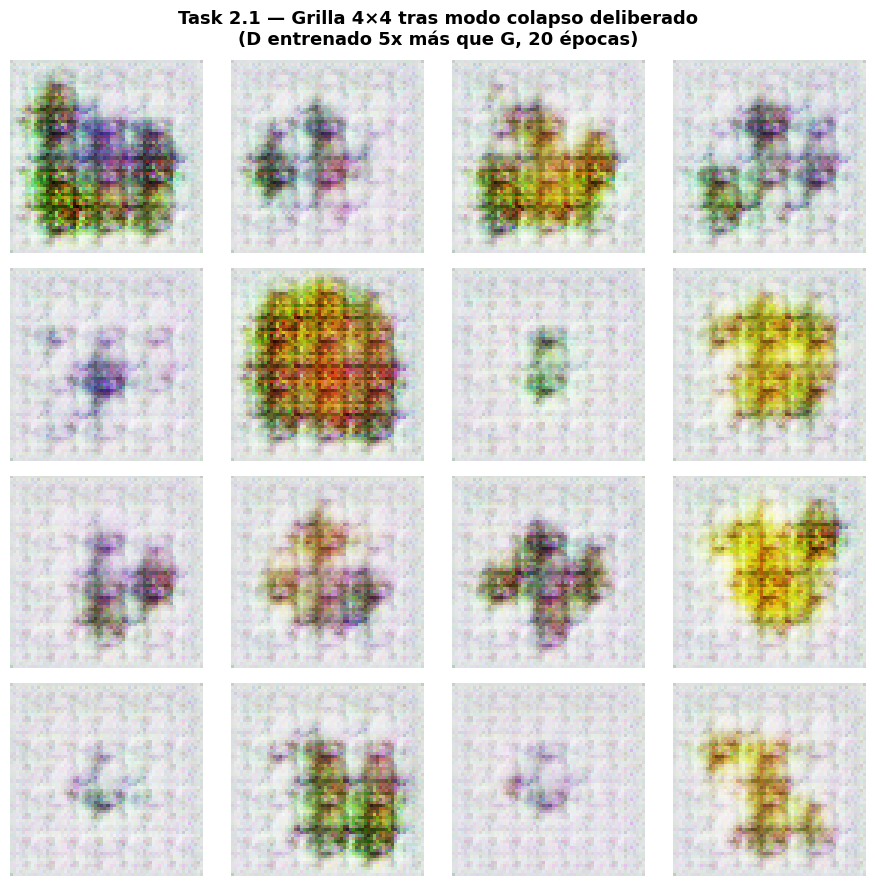

Grilla guardada: task2_1_collapse_grid.png


In [8]:
# Grilla 4x4 final
G.eval()
with torch.no_grad():
    collapse_imgs = G(fixed_noise).cpu()

collapse_denorm = (collapse_imgs * 0.5 + 0.5).clamp(0, 1)

fig, axes = plt.subplots(4, 4, figsize=(9, 9))
fig.suptitle(
    'Task 2.1 — Grilla 4×4 tras modo colapso deliberado\n'
    f'(D entrenado {D_STEPS}x más que G, {NUM_EPOCHS} épocas)',
    fontsize=13, fontweight='bold'
)
for i, ax in enumerate(axes.flatten()):
    ax.imshow(collapse_denorm[i].permute(1,2,0).numpy())
    ax.axis('off')

plt.tight_layout()
plt.savefig('task2_1_collapse_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grilla guardada: task2_1_collapse_grid.png')

In [9]:
# Diversidad cuantitativa
# Medir varianza píxel a píxel entre las 16 imágenes generadas
imgs_flat = collapse_denorm.view(16, -1)
pixel_std  = imgs_flat.std(dim=0).mean().item()
print(f'Desviación estándar promedio entre imágenes generadas: {pixel_std:.4f}')
print('(Valores cercanos a 0 indican baja diversidad — modo colapso confirmado)')

Desviación estándar promedio entre imágenes generadas: 0.1077
(Valores cercanos a 0 indican baja diversidad — modo colapso confirmado)


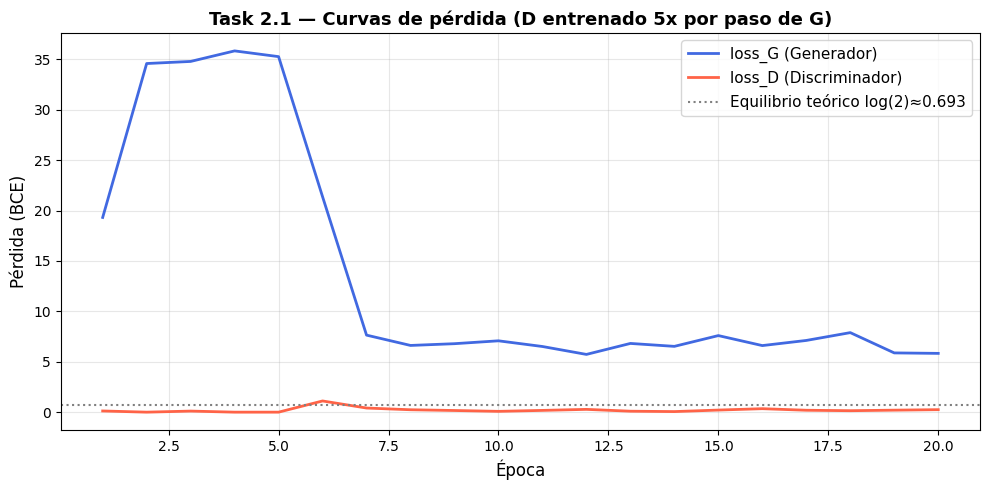

Curvas guardadas: task2_1_loss_curves.png


In [10]:
# Curvas de pérdid
epochs_ax = list(range(1, NUM_EPOCHS + 1))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs_ax, history_loss_G, label='loss_G (Generador)',
        color='royalblue', linewidth=2)
ax.plot(epochs_ax, history_loss_D, label='loss_D (Discriminador)',
        color='tomato', linewidth=2)
ax.axhline(y=np.log(2), color='gray', linestyle=':', linewidth=1.5,
           label=f'Equilibrio teórico log(2)≈{np.log(2):.3f}')
ax.set_xlabel('Época', fontsize=12)
ax.set_ylabel('Pérdida (BCE)', fontsize=12)
ax.set_title(
    f'Task 2.1 — Curvas de pérdida (D entrenado {D_STEPS}x por paso de G)',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task2_1_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Curvas guardadas: task2_1_loss_curves.png')

## Respuestas teóricas

---

### a) ¿Por qué entrenar D muchas más veces que G induce el modo colapso?

La pérdida del generador con el truco de Goodfellow es:

$$\mathcal{L}_G = -\mathbb{E}_{z}[\log D(G(z))]$$

Su gradiente respecto a los parámetros $\theta_G$ es:

$$\nabla_{\theta_G}\mathcal{L}_G = -\mathbb{E}_{z}\left[\frac{1}{D(G(z))} \cdot \nabla_{\theta_G} D(G(z))\right]$$

Cuando D se entrena 5 veces por cada paso de G, converge rápidamente a un discriminador casi óptimo que aprende a asignar $D(G(z)) \approx 0$ para **toda** salida del generador (sin importar cuál sea $z$). Sustituyendo:

$$D(G(z)) \approx 0 \implies \log D(G(z)) \to -\infty, \quad \text{pero} \quad \frac{d}{dx}\log(x)\big|_{x\to 0^+} = \frac{1}{x} \to +\infty$$

Sin embargo, en la práctica la función sigmoide satura: cuando $D(G(z)) \approx 0$ la activación pre-sigmoide es $\ll 0$, y el gradiente de la sigmoide en esa región es $\sigma'(x) = \sigma(x)(1-\sigma(x)) \approx 0$. Por lo tanto:

$$\nabla_{\theta_G}\mathcal{L}_G \approx 0$$

**G no recibe señal útil.** Como G se actualiza con gradiente nulo, sus parámetros dejan de cambiar. Esto colapsa el modo: G aprende a producir una sola salida (o un conjunto muy pequeño) que el D ya ha descartado permanentemente. El generador **no puede recuperarse** porque para que el gradiente sea útil nuevamente necesitaría que D le asigne probabilidades mayores a sus salidas, pero D sigue entrenándose y reforzando $D(G(z))\approx 0$. El sistema queda atrapado en un mínimo degenerado.

---

### b) ¿Qué valor toma $D^*(x)$ para las imágenes que G produce repetidamente?

En clase se derivó el discriminador óptimo:

$$D^*(x) = \frac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_G(x)}$$

En el modo colapso, G colapsa hacia una distribución $p_G$ concentrada en un punto (o región muy pequeña) del espacio de imágenes que **no pertenece al soporte de $p_{\text{data}}$**. Para esas imágenes repetidas:

$$p_{\text{data}}(x) \approx 0, \quad p_G(x) \gg 0$$

Por lo tanto:

$$D^*(x) = \frac{0}{0 + p_G(x)} = 0$$

Esto confirma lo observado experimentalmente: el discriminador asigna probabilidad $\approx 0$ ("falso con certeza") a todas las imágenes que G genera, lo que es consistente con la pérdida $\text{loss}_G$ muy alta observada en las curvas.

---

### c) Modificación para prevenir el modo colapso (sin cambiar proporción de pasos)

**Propuesta: Gradient Penalty sobre D (como en WGAN-GP)**

Agregar al loss del discriminador un término de penalización sobre la norma del gradiente:

$$\mathcal{L}_D^{\text{GP}} = \mathcal{L}_D + \lambda \cdot \mathbb{E}_{\hat{x}}\left[(\|\nabla_{\hat{x}} D(\hat{x})\|_2 - 1)^2\right]$$

donde $\hat{x} = \epsilon x_{\text{real}} + (1-\epsilon) G(z)$, $\epsilon \sim U[0,1]$.

**¿Por qué funcionaría?**

La penalización fuerza a D a ser una función 1-Lipschitz, lo que impide que el discriminador colapse sus salidas a 0 de forma abrupta. Al controlar la magnitud del gradiente de D, se garantiza que $D(G(z))$ no caiga a 0 para toda $z$ simultáneamente, preservando un gradiente $\nabla_{\theta_G}\mathcal{L}_G$ no nulo. G entonces sigue recibiendo señal de entrenamiento útil incluso cuando D es más fuerte, evitando el colapso.

In [11]:
CHECKPOINT_DIR = os.path.join(BASE_DIR, 'checkpoints')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

torch.save({
    'G_state_dict': G.state_dict(),
    'D_state_dict': D.state_dict(),
    'history_loss_G': history_loss_G,
    'history_loss_D': history_loss_D,
    'fixed_noise': fixed_noise.cpu(),
}, os.path.join(CHECKPOINT_DIR, 'dl-ht2-task2.1-checkpoint.pth'))

print('Guardado: dl-ht2-task2.1-checkpoint.pth')

Guardado: ds-ht2-task2.1-checkpoint.pth
